# Urban Networks I

Overview of today's topics:
  - Network modeling and analysis with NetworkX
  - Spatial network modeling and analysis with OSMnx and OpenStreetMap

For more, see:
  - OSMnx [Documentation](https://osmnx.readthedocs.io/)
  - OSMnx [Examples Gallery](https://github.com/gboeing/osmnx-examples)

In [2]:
!curl -s -o pyproject.toml https://raw.githubusercontent.com/gboeing/osmnx-workshop/refs/heads/main/pyproject.toml && uv pip install -r pyproject.toml

Using Python 3.12.12 environment at: /usr
Resolved 114 packages in 943ms
Prepared 8 packages in 550ms
Installed 8 packages in 125ms
 + async-lru==2.2.0
 + jedi==0.19.2
 + json5==0.13.0
 + jupyter-lsp==2.3.0
 + jupyterlab==4.5.6
 + jupyterlab-server==2.28.0
 + osmnx==2.1.0
 + rio-vrt==0.3.1


In [3]:
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

# configure OSMnx
ox.settings.log_console = True
print(ox.__version__)

2.1.0


## 1. Network analysis with NetworkX

Networks let you represent structure and interaction among the components of a system. In analytics, they let you go beyond models that average across individuals/components or treat the population/system as a monolith. Networks are useful when the system's structure is nontrivial.

A network is a set of objects (called nodes or vertices) connected to each other by a set of connections (called edges or links). A graph is a mathematical model of a network: usually used synonymously. You can represent a graph as an adjacency matrix to use the tools of linear algebra to analyze it. You can also simulate dynamics and flows on it.

A trivial (simple) network is undirected, unweighted, and lacks self-loops or parallel edges. A nontrivial (complex) network may be directed and weighted and have self-loops and parallel edges. A spatial network is a network that is spatially embedded. That means its nodes and/or edges have locations in space. A spatial network is defined by both its geometry (positions, distances, angles, etc) and its topology (connections and configurations).

Examples:

  - street networks
  - airline routes
  - rail lines
  - capital flows
  - spread of contagious diseases

We can analyze a network in various ways. To take street networks as an example, you can measure its compactness via intersection density, its connectedness via average node degree, or the relative importance of different nodes via centrality. Betweenness centrality measures what share of all shortest paths in a network pass through each node. Closeness centrality measures the average distance between a node and all other nodes in the network.

In [4]:
# create a random small-world graph of a social network
G = nx.watts_strogatz_graph(n=100, k=5, p=0.1, seed=0)

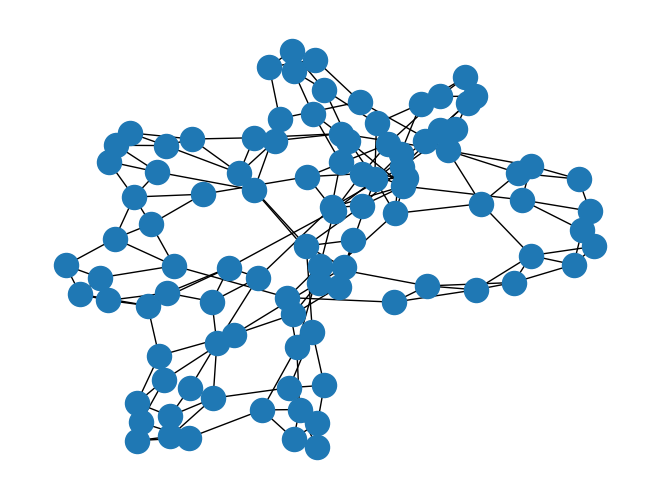

In [5]:
nx.draw(G)

In [6]:
# how many nodes and edges?
print(len(G.nodes))
print(len(G.edges))

100
200


In [7]:
# assign random ages to each person in the network
randoms = np.random.randint(low=18, high=90, size=len(G.nodes))
ages = {node: age for node, age in zip(G.nodes, randoms)}
nx.set_node_attributes(G, values=ages, name="age")

In [8]:
# assign random "social distance" to each edge in the network
# social distance is the inverse of how often they hang out each year
hangout_counts = np.random.randint(low=1, high=100, size=len(G.edges))
distances = {edge: 1 / hangout_count for edge, hangout_count in zip(G.edges, hangout_counts)}
nx.set_edge_attributes(G, values=distances, name="distance")

In [12]:
# view the nodes and optionally show their attribute data
G.nodes(data=True)

NodeDataView({0: {'age': np.int64(19)}, 1: {'age': np.int64(54)}, 2: {'age': np.int64(29)}, 3: {'age': np.int64(71)}, 4: {'age': np.int64(52)}, 5: {'age': np.int64(76)}, 6: {'age': np.int64(45)}, 7: {'age': np.int64(34)}, 8: {'age': np.int64(27)}, 9: {'age': np.int64(33)}, 10: {'age': np.int64(76)}, 11: {'age': np.int64(68)}, 12: {'age': np.int64(44)}, 13: {'age': np.int64(78)}, 14: {'age': np.int64(79)}, 15: {'age': np.int64(56)}, 16: {'age': np.int64(66)}, 17: {'age': np.int64(44)}, 18: {'age': np.int64(85)}, 19: {'age': np.int64(59)}, 20: {'age': np.int64(60)}, 21: {'age': np.int64(31)}, 22: {'age': np.int64(25)}, 23: {'age': np.int64(20)}, 24: {'age': np.int64(51)}, 25: {'age': np.int64(31)}, 26: {'age': np.int64(70)}, 27: {'age': np.int64(65)}, 28: {'age': np.int64(73)}, 29: {'age': np.int64(46)}, 30: {'age': np.int64(77)}, 31: {'age': np.int64(20)}, 32: {'age': np.int64(47)}, 33: {'age': np.int64(37)}, 34: {'age': np.int64(28)}, 35: {'age': np.int64(79)}, 36: {'age': np.int64(65)

In [13]:
# view the edges and optionally show their attribute data
# these are undirected edges, and there cannot be parallel edges
G.edges   (data=True)

EdgeDataView([(0, 1, {'distance': np.float64(0.022727272727272728)}), (0, 99, {'distance': np.float64(0.023255813953488372)}), (0, 2, {'distance': np.float64(0.125)}), (0, 98, {'distance': np.float64(0.038461538461538464)}), (1, 2, {'distance': np.float64(0.011904761904761904)}), (1, 3, {'distance': np.float64(0.030303030303030304)}), (1, 99, {'distance': np.float64(0.02564102564102564)}), (2, 3, {'distance': np.float64(0.5)}), (2, 4, {'distance': np.float64(0.05)}), (2, 17, {'distance': np.float64(0.011904761904761904)}), (3, 4, {'distance': np.float64(0.015151515151515152)}), (3, 5, {'distance': np.float64(0.01020408163265306)}), (4, 5, {'distance': np.float64(0.02127659574468085)}), (4, 6, {'distance': np.float64(0.030303030303030304)}), (4, 92, {'distance': np.float64(0.018518518518518517)}), (5, 6, {'distance': np.float64(0.011235955056179775)}), (5, 7, {'distance': np.float64(0.07692307692307693)}), (6, 7, {'distance': np.float64(0.5)}), (6, 73, {'distance': np.float64(0.14285714

In [11]:
# calculate the shortest path between two nodes
path1 = nx.shortest_path(G, source=0, target=50)
path1

[0, 2, 17, 18, 20, 87, 50]

In [14]:
# calculate the shortest weighted path between two nodes
path2 = nx.shortest_path(G, source=0, target=50, weight="distance")
path2

[0, 99, 97, 95, 93, 91, 89, 88, 87, 50]

In [15]:
# calculate node betweenness centrality across the network
bc = nx.betweenness_centrality(G, weight="distance")
pd.Series(bc).describe()

,0
count,100.000000
mean,0.055119
std,0.047941
min,0.000000
25%,0.019893
50%,0.041744
75%,0.081633
max,0.201402


In [ ]:
# now it's your turn
# try changing the social distance between our people, then recompute a shortest path

There is nothing explicitly spatial about the graph above. Although it models people and their relationships, it captures nothing about their positions in space. Now let's look at real-world spatial networks.

## 2. Spatial networks and OSMnx

OSMnx lets you download, model, analyze, and visualize street networks (and any other spatial data) anywhere in the world from OpenStreetMap.

OSMnx is built on top of GeoPandas, NetworkX, and matplotlib and interacts with OpenStreetMap’s APIs to:

  - Download and model street networks or other networked infrastructure anywhere in the world with a single line of code
  - Download any other spatial geometries, place boundaries, building footprints, or points of interest as a GeoDataFrame
  - Download by city name, polygon, bounding box, or point/address + network distance
  - Download drivable, walkable, bikeable, or all street networks
  - Download node elevations and calculate edge grades (inclines)
  - Impute missing speeds and calculate graph edge travel times
  - Simplify and correct the network’s topology to clean-up nodes and consolidate intersections
  - Fast map-matching of points, routes, or trajectories to nearest graph edges or nodes
  - Save networks to disk as shapefiles, GeoPackages, and GraphML
  - Save/load street network to/from a local .osm XML file
  - Conduct topological and spatial analyses to automatically calculate dozens of indicators
  - Calculate and visualize street bearings and orientations
  - Calculate and visualize shortest-path routes that minimize distance, travel time, elevation, etc
  - Visualize street networks as a static map or interactive Leaflet web map
  - Visualize travel distance and travel time with isoline and isochrone maps
  - Plot figure-ground diagrams of street networks and building footprints

More info:

  - [OSMnx documentation](https://osmnx.readthedocs.io)
  - [Examples, demos, tutorials](https://github.com/gboeing/osmnx-examples)

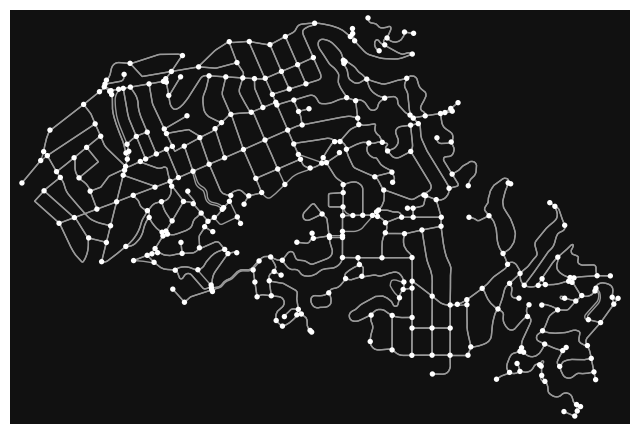

In [16]:
# download/model a street network for some city then visualize it
place = "Piedmont, California, USA"
G = ox.graph.graph_from_place(place, network_type="drive")
fig, ax = ox.plot.plot_graph(G)

OSMnx geocodes the query "Piedmont, California, USA" to retrieve the place boundaries of that city from the Nominatim API, retrieves the drivable street network data within those boundaries from the Overpass API, constructs a graph model, then simplifies/corrects its topology such that nodes represent intersections and dead-ends and edges represent the street segments linking them.

In [17]:
# look at the first 10 nodes: these are OSM IDs
list(G.nodes)[0:10]

[53017091,
 53018397,
 53018399,
 53018402,
 53018404,
 53018410,
 53018411,
 53021742,
 53021743,
 53021750]

In [18]:
# look at the first 10 edges: u, v, key
list(G.edges)[0:10]

[(53017091, 53064327, 0),
 (53017091, 53075599, 0),
 (53018397, 53018399, 0),
 (53018397, 53018411, 0),
 (53018397, 53097980, 0),
 (53018399, 53018402, 0),
 (53018399, 53018397, 0),
 (53018399, 53078914, 0),
 (53018402, 53018399, 0),
 (53018402, 53018404, 0)]

In [19]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

OSMnx models all networks as NetworkX `MultiDiGraph` objects. You can convert to:

  - undirected NetworkX MultiGraphs
  - NetworkX DiGraphs without (possible) parallel edges
  - GeoPandas node/edge GeoDataFrames

In [20]:
# convert your graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
gdf_nodes.head()

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
53017091,37.826250,-122.247604,3,NaN,NaN,POINT (-122.2476 37.82625)
53018397,37.824220,-122.247198,3,stop,NaN,POINT (-122.2472 37.82422)
53018399,37.824900,-122.246113,3,NaN,NaN,POINT (-122.24611 37.8249)
53018402,37.825406,-122.245338,3,NaN,NaN,POINT (-122.24534 37.82541)
53018404,37.825948,-122.244467,3,NaN,NaN,POINT (-122.24447 37.82595)


In [21]:
gdf_edges.head()

osmid      highway          name  oneway reversed  \
u        v        key                                                          
53017091 53064327 0      6345781  residential   Rose Avenue   False    False   
         53075599 0      6345781  residential   Rose Avenue   False     True   
53018397 53018399 0      6327298  residential   Lake Avenue   False    False   
         53018411 0    196739937     tertiary  Linda Avenue   False    False   
         53097980 0    196739937     tertiary  Linda Avenue   False     True   

                           length  \
u        v        key               
53017091 53064327 0    230.124412   
         53075599 0    122.234915   
53018397 53018399 0    121.647438   
         53018411 0     37.593760   
         53097980 0    100.205124   

                                                                geometry  \
u        v        key                                                      
53017091 53064327 0    LINESTRING (-122.2476 37.82625, -122.2475 37.8...   
         53075599 0    LINESTRING (-122.2476 37.82625, -122.24771 37....   
53018397 53018399 0    LINESTRING (-122.2472 37.82422, -122.24712 37....   
         53018411 0    LINESTRING (-122.2472 37.82422, -122.24713 37....   
         53097980 0    LINESTRING (-122.2472 37.82422, -122.24772 37....   

                      lanes maxspeed bridge junction  
u        v        key                                 
53017091 53064327 0     NaN      NaN    NaN      NaN  
         53075599 0     NaN      NaN    NaN      NaN  
53018397 53018399 0     NaN      NaN    NaN      NaN  
         53018411 0     NaN      NaN    NaN      NaN  
         53097980 0     NaN      NaN    NaN      NaN

You can create a graph from node/edge GeoDataFrames, as long as gdf_nodes is indexed by osmid and gdf_edges is multi-indexed by u, v, key (following normal MultiDiGraph structure). This allows you to load graph node/edge shapefiles or GeoPackage layers as GeoDataFrames then convert to a MultiDiGraph for graph analytics.

In [22]:
# convert node/edge GeoPandas GeoDataFrames to a NetworkX MultiDiGraph
G2 = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)
print(len(G2.nodes))
print(len(G2.edges))

352
944


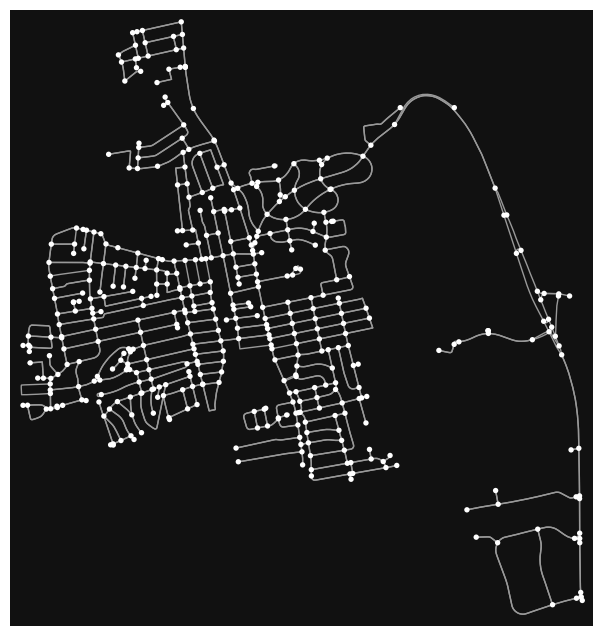

In [23]:
# now it's your turn
# download a graph of a different (small-ish) town, then plot it
place = "Port Washington, New York, USA"
G = ox.graph.graph_from_place(place, network_type="drive")
fig, ax = ox.plot.plot_graph(G)

## Basic street network stats

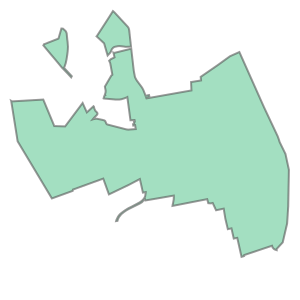

In [24]:
# get our study site's geometry
gdf = ox.geocoder.geocode_to_gdf(place)
gdf_proj = ox.projection.project_gdf(gdf)
geom_proj = gdf_proj["geometry"].iloc[0]
geom_proj

In [25]:
# what size area does our study site cover in square meters?
area_m = geom_proj.area
area_m

14729052.157470949

In [26]:
# project the graph (automatically) then check its new CRS
G_proj = ox.projection.project_graph(G)
G_proj.graph["crs"]

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
# show some basic stats about the (projected) network
ox.stats.basic_stats(G_proj, area=area_m, clean_int_tol=10)

{'n': 459,
 'm': 1208,
 'k_avg': 5.2636165577342044,
 'edge_length_total': 155559.21664126447,
 'edge_length_avg': 128.77418596131164,
 'streets_per_node_avg': 2.810457516339869,
 'streets_per_node_counts': {0: 0, 1: 72, 2: 7, 3: 319, 4: 58, 5: 3},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1568627450980392,
  2: 0.015250544662309368,
  3: 0.6949891067538126,
  4: 0.12636165577342048,
  5: 0.006535947712418301},
 'intersection_count': 387,
 'street_length_total': 81765.44502981353,
 'street_segment_count': 638,
 'street_length_avg': 128.15900474892405,
 'circuity_avg': 1.067487990308011,
 'self_loop_proportion': 0.007836990595611285,
 'clean_intersection_count': 364,
 'node_density_km': 31.162901393297297,
 'intersection_density_km': 26.274603135525172,
 'edge_density_km': 10561.386773442911,
 'street_density_km': 5551.303923405555,
 'clean_intersection_density_km': 24.71306341429241}

More stats [documentation](https://osmnx.readthedocs.io/en/stable/osmnx.html#module-osmnx.stats)

In [28]:
# save graph to disk as geopackage (for GIS) or GraphML file (for Gephi etc)
ox.io.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.io.save_graphml(G, filepath="./data/mynetwork.graphml")

## Visualize street centrality

Here we plot the street network and color its edges (streets) by their relative closeness centrality.

In [29]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

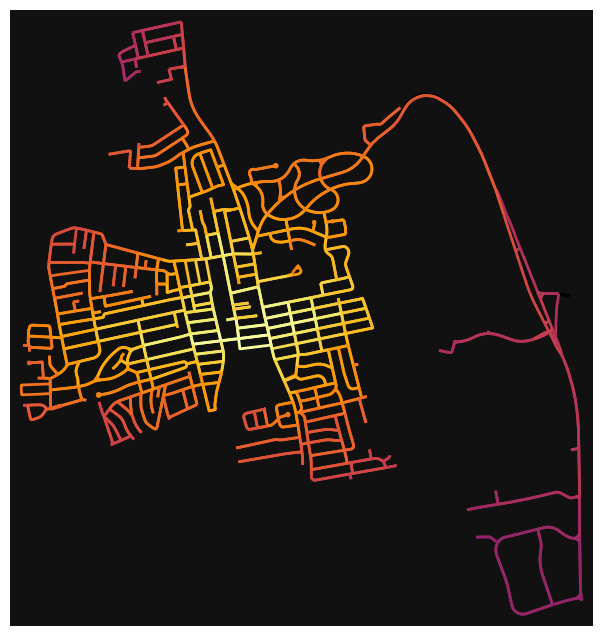

In [30]:
# color edges in original graph with centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

## Routing

In [31]:
# impute missing edge speeds then calculate edge (free-flow) travel times
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

In [47]:
# get the nearest network nodes to two lat/lng points
orig = ox.distance.nearest_nodes(G, -122.245846, 37.828903)
dest = ox.distance.nearest_nodes(G, -122.215006, 37.812303)

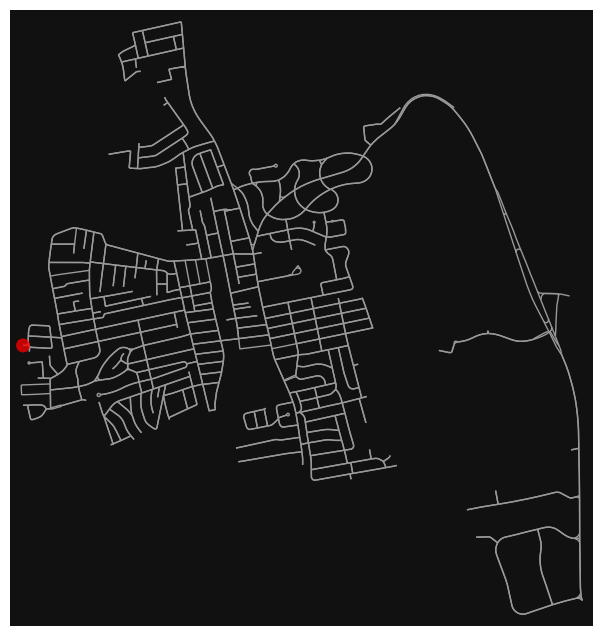

In [48]:
# find the shortest path between these nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [49]:
# how long is our route in meters?
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
sum(edge_lengths)

ValueError: Graph contains no edges.

In [36]:
# how far is it between these two nodes as the crow flies (haversine)?
ox.distance.great_circle(
    G.nodes[orig]["y"], G.nodes[orig]["x"], G.nodes[dest]["y"], G.nodes[dest]["x"]
)

np.float64(0.0)

In [ ]:
# now it's your turn
# how circuitous is this route?
# try plotting it differently: change the colors and node/edge sizes

## Get networks other ways

make queries less ambiguous to help the geocoder out, if it's not finding what you're looking for

In [ ]:
# you can make query an unambiguous dict to help the geocoder find it
place = {"city": "San Francisco", "state": "California", "country": "USA"}
G = ox.graph.graph_from_place(place, network_type="drive", truncate_by_edge=True)
fig, ax = ox.plot.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [ ]:
# you can get networks anywhere in the world
G = ox.graph.graph_from_place("Sinalunga, Italy", network_type="all")
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_linewidth=0.5)

In [ ]:
# or get network by address, coordinates, bounding box, or any custom polygon
# ...useful when OSM just doesn't already have a polygon for the place you want
lewis_hall = (34.019267, -118.283566)
one_mile = 1609  # meters
G = ox.graph.graph_from_point(lewis_hall, dist=one_mile, network_type="drive")
fig, ax = ox.plot.plot_graph(G, node_size=0)

Consider study area boundaries and the artificial perimeter problem.

In [ ]:
# now it's your turn
# create a graph of your hometown
# then calculate the shortest path between two points of your choice

## Get other networked infrastructure types

...like rail or electric grids or even the canals of Venice and Amsterdam, using the `custom_filter` parameter. See the Overpass Query Language documentation for query usage details.

In [ ]:
# get NY subway rail network
G = ox.graph.graph_from_place(
    "New York City, New York, USA",
    retain_all=False,
    truncate_by_edge=True,
    simplify=True,
    custom_filter='["railway"~"subway"]',
)

fig, ax = ox.plot.plot_graph(G, node_size=0, edge_color="c", edge_linewidth=0.2)

## Get any geospatial entities' geometries and attributes

Use the `features` module to download entities, such as local amenities, points of interest, or building footprints, and turn them into a GeoDataFrame.

In [ ]:
# get all building footprints in some neighborhood
place = "Loop, Chicago, IL, USA"
tags = {"building": True}
gdf = ox.features.features_from_place(place, tags)
gdf.shape

In [ ]:
fig, ax = ox.plot.plot_footprints(gdf, figsize=(3, 3))

In [ ]:
# get all parks and bus stops in some neighborhood
tags = {"leisure": "park", "highway": "bus_stop"}
gdf = ox.features.features_from_place(place, tags)
gdf.shape

In [ ]:
# restaurants near the empire state buildings
address = "350 5th Ave, New York, NY 10001"
tags = {"amenity": "restaurant"}
gdf = ox.features.features_from_address(address, tags=tags, dist=500)
gdf[["name", "cuisine", "geometry"]].dropna().head()

In [ ]:
# now it's your turn
# find all the rail stations around central CDMX
# hint, the tag is railway and the value is station:
# https://wiki.openstreetmap.org/wiki/Tag:railway%3Dstation